# Import data

Start by importing the file downloaded from the Georgia Secretary of State's website.

In [1]:
import pandas as pd

# Contains some code that needs to be used by other notebooks.
import sos

# 2024 election data for now
df = pd.read_json('./export-2024NovGen.json', typ='series')
df = sos.prepare_export_df(df, use_advanced=True)

df

electionDate                                           2024-11-05
electionName                            November General Election
createdAt                            2025-01-30T13:59:59.5881725Z
results         {'id': '09378a07-e6cf-4f66-be7c-ca4aa534f99a',...
localResults                                           id     ...
dtype: object

# State Senate races

In [2]:
import utils

def prep(chamber: pd.DataFrame):
    chamber['raceStatus'] = chamber['ballotOptions'].apply(lambda x: 'Final' 
                                                            if len(x) == 1 else 'Leading')
    chamber['leadingParty'] = chamber['ballotOptions'].apply(lambda x: 
                                                            sorted(x, key=lambda y: y['voteCount'], 
                                                                    reverse=True)[0]['politicalParty'])
    chamber['changingParties'] = chamber.apply(lambda x: x['incumbentParty'] != x['leadingParty'], axis=1) 
    return chamber

parties = ['Rep', 'Dem']

def table_of_seats_won(chamber: pd.DataFrame):
    table = pd.crosstab(chamber['leadingParty'], 
                        [chamber['raceStatus']], 
                        rownames=['leadingParty'],
                        colnames=['raceStatus'])
    table['Total'] = table['Final'] + table['Leading']
    table = table.sort_values('Total', ascending=False)
    return table

def seat_changes(chamber: pd.DataFrame):
    changes = pd.DataFrame([], index=parties, 
                           columns=pd.MultiIndex.from_tuples(utils.make_tuple_matrix(['Final', 'Leading'], ['Gains', 'Losses', 'Change'])))
    for prg in ['Final', 'Leading']:
        changes[(prg, 'Gains')] = [len(chamber[(chamber['changingParties']) & 
                                               (chamber['leadingParty'] == party) &
                                               (chamber['raceStatus'] == prg)])
                                               for party in parties]
        changes[(prg, 'Losses')] = [len(chamber[(chamber['incumbentParty'] == party) & 
                                                (chamber['changingParties']) &
                                                (chamber['raceStatus'] == prg)]) 
                                                for party in parties]
        changes[(prg, 'Change')] = changes[prg, 'Gains'] - changes[prg, 'Losses']
        #changes[(prg, 'Change')] = changes[prg, 'Change'].apply(lambda x: f'+{x}' if x > 0 else f'{x}')
        changes = changes.drop([(prg, 'Gains'), (prg, 'Losses')], axis=1)
    changes['Total', 'Change'] = changes['Final', 'Change'] + changes['Leading', 'Change']
    changes = changes.map(utils.format_delta)
    return changes

def seats_flipped(chamber: pd.DataFrame):
    flipped = pd.DataFrame(chamber)
    flipped = flipped[flipped['changingParties']]
    flipped = flipped.set_index('name')
    flipped = flipped.reindex(columns=['incumbentParty', 'leadingParty', 'raceStatus', 'ballotOptions'])
    flipped.columns = ['Incumbent Party', 'Leading Party', 'Race Status', 'ballotOptions']
    flipped['Leading Ballot Option'] = \
        flipped['ballotOptions'].apply(lambda x: sorted(x, key=lambda y: y['voteCount'], reverse=True)[0])
    flipped['Leading Candidate'] = \
        flipped['Leading Ballot Option'].apply(lambda x: x['name'].replace(' (Rep)', '').replace(' (Dem)', ''))
    flipped = flipped.drop(['Leading Ballot Option', 'ballotOptions'], axis=1)
    if len(flipped) == 0:
        return 'No seats flipped'
    return flipped

# Import incumbent parties data

def make_chamber_race(chamber, district):
    return f'{chamber} - District {district}'

incumbent_parties = pd.read_csv('incumbent_parties.csv')
incumbent_parties['name'] = \
incumbent_parties.apply(lambda r: make_chamber_race(r['Chamber'], r['District']), axis=1)
incumbent_parties

,Chamber,District,incumbentParty,name
0,State Senate,1,Rep,State Senate - District 1
1,State Senate,2,Dem,State Senate - District 2
2,State Senate,3,Rep,State Senate - District 3
3,State Senate,4,Rep,State Senate - District 4
4,State Senate,5,Dem,State Senate - District 5
...,...,...,...,...
245,United States House of Representatives,10,Rep,United States House of Representatives - Distr...
246,United States House of Representatives,11,Rep,United States House of Representatives - Distr...
247,United States House of Representatives,12,Rep,United States House of Representatives - Distr...
248,United States House of Representatives,13,Dem,United States House of Representatives - Distr...


In [3]:
ss: pd.DataFrame = df['results']['ballotItems']
ss = ss[ss['name'].apply(lambda x: 'State Senate' in x)]
ss = ss.join(incumbent_parties.set_index('name')['incumbentParty'], on='name')
ss = prep(ss)
table_of_seats_won(ss)

raceStatus,Final,Leading,Total
leadingParty,,,
Rep,18,15,33
Dem,15,8,23


In [4]:
seat_changes(ss)

,Final,Leading,Total
,Change,Change,Change
Rep,0,0,0
Dem,0,0,0


In [5]:
seats_flipped(ss)

'No seats flipped'

# State House

In [6]:
sh: pd.DataFrame = df['results']['ballotItems']
sh = sh[sh['name'].apply(lambda x: 'State House' in x)]
sh = sh.join(incumbent_parties.set_index('name')['incumbentParty'], on='name')
sh = prep(sh)

In [7]:
table_of_seats_won(sh)

raceStatus,Final,Leading,Total
leadingParty,,,
Rep,47,53,100
Dem,43,37,80


In [8]:
seat_changes(sh)

,Final,Leading,Total
,Change,Change,Change
Rep,0,+1,+1
Dem,0,-1,-1


In [9]:
seats_flipped(sh)

,Incumbent Party,Leading Party,Race Status,Leading Candidate
name,,,,
State House of Representatives - District 121,Dem,Rep,Leading,Marcus A. Wiedower (I)


# Ballot Questions

In [10]:
import utils

bqs = df['results']['ballotItems']
bqs = bqs[bqs['name'].apply(lambda x: 'Proposed Constitutional Amendment' in x)]
bqs = bqs.set_index('name')
bqs['ballotOptions'] = bqs['ballotOptions'].apply(lambda x: pd.DataFrame.from_records(x).set_index('name'))
bqs['Yes'] = bqs['ballotOptions'].apply(lambda x: x.loc['Yes', 'voteCount'])
bqs['No'] = bqs['ballotOptions'].apply(lambda x: x.loc['No', 'voteCount'])
stwd_totals = pd.DataFrame(index=bqs.index, columns=pd.MultiIndex.from_tuples(utils.make_tuple_matrix(['Yes', 'No'], ['Votes', 'Share'])))
stwd_totals['Total'] = 0
for option in ['Yes', 'No']:
    stwd_totals[(option, 'Votes')] = bqs[option]
    stwd_totals['Total'] += bqs[option]
for option in ['Yes', 'No']:
    stwd_totals[(option, 'Share')] = (stwd_totals[(option, 'Votes')] / stwd_totals['Total'] * 100).round(utils.STD_ROUND)
    stwd_totals[(option, 'Votes')] = stwd_totals[(option, 'Votes')].map(utils.format_votes) 
stwd_totals['Total'] = stwd_totals['Total'].map(utils.format_votes) 
stwd_totals

Yes                No         \
                                         Votes  Share      Votes  Share   
name                                                                      
Proposed Constitutional Amendment 1  3,094,322  62.92  1,823,529  37.08   
Proposed Constitutional Amendment 2  2,525,406  51.89  2,341,612  48.11   

                                         Total  
                                                
name                                            
Proposed Constitutional Amendment 1  4,917,851  
Proposed Constitutional Amendment 2  4,867,018

# Map dashboard

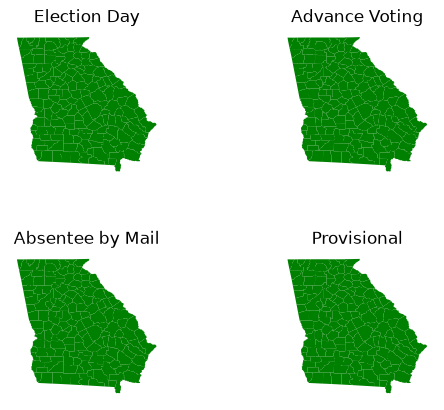

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import utils


fig, axes = plt.subplots(nrows=2, ncols=2)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
counties = utils.import_county_map()
df['localResults']['name'] = df['localResults']['name'].apply(lambda c: c.replace(' County', ''))
slots = [[0,0], [0,1], [1,0], [1,1]]
color = {
    'Not Reported': '#aaaaaa',
    'Partially Reported': '#767676',
    'Election Night Complete': '#242424',
    'Fully Reported': '#008000'
}
for x, vote_group in enumerate(sos.vote_methods):
    counties[vote_group] = df['localResults'].set_index('name')[vote_group]
    cmap = mcolors.ListedColormap([color[s] for s in counties[vote_group].unique()])
    ax = counties.plot(column=vote_group, ax=axes[*slots[x]], cmap=cmap)
    ax.set_title(vote_group)
    ax.set_axis_off()

plt.show()

In [12]:
import geopandas

regions_metro = geopandas.read_file('./regions/regions_metro.json')
regions_metro = regions_metro.set_index('index')
#regions_metro[regions_metro['County'] == 'Newton']

Newton
Gwinnett
DeKalb


KeyError: "['WOODWARD'] not in index"

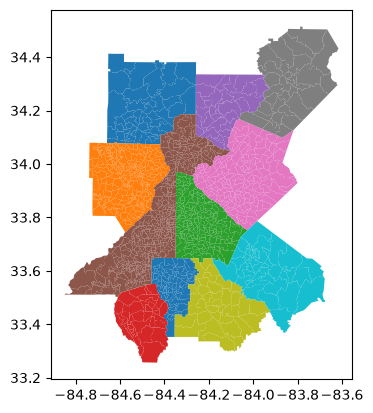

In [13]:
benchmark_race = 'President of the US' # Needs to be governor's race for 2026
year = '2026'

precincts = regions_metro[regions_metro['Election'].isin([year, '*'])]
precincts.plot(column='County')
lr = df['localResults']
lr = lr[lr['name'].map(lambda x: x.replace(' County', '')).isin(precincts['County'].unique())]
lr = lr.set_index('name')
for county in lr.index:
    c = lr.loc[county]
    race = c['ballotItems'].set_index('name').loc[benchmark_race]
    precincts_for_county = pd.DataFrame.from_records(race['ballotOptions'][0]['precinctResults'])
    precincts_for_county['name'] = precincts_for_county['name'].map(lambda x: x.upper())
    precincts_for_county = precincts_for_county.set_index('name')
    if county in ['Rockdale', 'Fayette', 'Hall']:
        continue
    print(county)
    precincts.loc[precincts_for_county.index.map(lambda x: x.upper()), 'Reporting Status'] = precincts_for_county['reportingStatus']
precincts.plot(column='Reporting Status')